# What???...Punctuation!!!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import string
import re
import datasets
import random

C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pre-Processsing
Loading of The Reddit Dataset and Extraction of 30% of training data.

In [2]:
from datasets import load_dataset

tldr = load_dataset("webis/tldr-17", split = 'train[:30%]') # only 30% of data is used to train 

C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\datasets\table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [3]:
# 3 random examples from the Webis-TLDR-17 TIFU dataset:
def show_random_elements(dataset, num_examples=3):
    picks = random.sample(range(len(dataset)), num_examples)
    for i in picks:
        print(dataset[i])
        print("-" * 150)

show_random_elements(tldr)

{'author': 'generalstateof', 'body': 'I\'ve never used drugs so I can\'t say much about that. But if there\'s one thing I know about its being bored. I\'m in school for engineering, I actually overload my schedule so I "Don\'t have time to think, thinking is the enemy, must focus".  Now that Summer is here things are starting to get worse, even though I\'m taking summer courses. I think I get how you feel with the boredom, there have been a few times I\'ve sat in my room for 5-7 days without leaving, no eating, no talking, not even going to the bathroom; the worst part about it is that I didn\'t even think it was that big of a deal at the time(and still don\'t sometimes). I personally just don\'t have the guts to kill myself, oddly enough I think I\'ve almost given up on giving up. When I\'m feeling bad, I just lie down and stare at the ceiling for a couple hours, days... week. \n\nTL;DR Stare at ceiling for a day and go "whelp, that was a thing" and continue living like you have been 

## Subreddit Selection
Here we find the top 10 subreddits in the data and we sort them in descending order

In [4]:
subreddit_count = {}

for subreddit in tldr['subreddit']:
    subreddit_count[subreddit] = subreddit_count.get(subreddit, 0) + 1

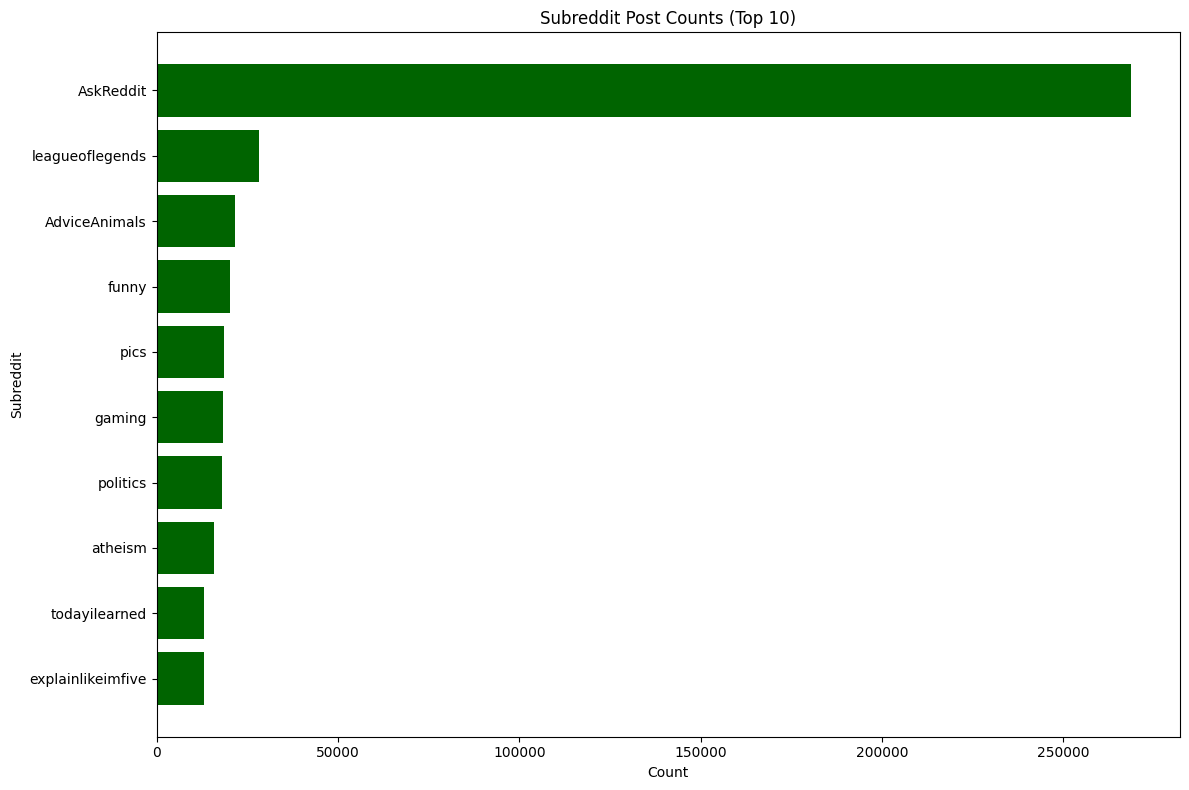

In [5]:
# Sort by count descending and take top 10
subs_10 = sorted(subreddit_count.items(), key=lambda x: x[1], reverse=True)[:10]
subreddits, counts = zip(*subs_10)

plt.figure(figsize=(12, 8))
plt.barh(subreddits, counts, color='darkgreen')
plt.xlabel('Count')
plt.ylabel('Subreddit')
plt.title('Subreddit Post Counts (Top 10)')
plt.gca().invert_yaxis()
plt.savefig("../figures/EDA_Top_10_Subreddits.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

In [6]:
# subreddits is a tuple of names from the chart above, e.g. ('AskReddit', 'tifu', ...)
top_10_subs = list(subreddits)

# filter dataset to only posts from those top 10 subreddits
dfilt = tldr.filter(lambda x: x['subreddit'] in top_10_subs)
print(top_10_subs)

['AskReddit', 'leagueoflegends', 'AdviceAnimals', 'funny', 'pics', 'gaming', 'politics', 'atheism', 'todayilearned', 'explainlikeimfive']


## Feature Engineering
### Tokenization

In [7]:
def get_tokens(text):
    return nltk.word_tokenize(text)

def get_sentences(text):
    return nltk.sent_tokenize(text)

In [8]:
def get_posts(subreddit, max_posts):
    posts = []
    for row in dfilt:
        if row["subreddit"] != subreddit:
            continue
        text = str(row["content"]).strip()
        if text:
            posts.append(text)
        if len(posts) >= max_posts:
            break
    return posts

MAX_POSTS= 1500

### Chosen Punctuation Expressions
We have chosen the following punctuation patterns i.e expressive patterns:
- ...  
- ???? 
- !!!!! 
- ?!?! 
- !?!? 

In addition, we have chosen Periods, Exclamation points and Question Marks for our analysis.

In [9]:
EXPRESSIVE_PATTERNS = {
    "ELLIPSIS": r"\.{3,}",       # ..., ...., .....
    "MULTI_QUEST": r"\?{2,}",        # ??, ???, ?????
    "MULTI_EXCL": r"!{2,}",         # !!, !!!, !!!!!!
    "QUEST-EXCL": r"(?:\?!){2,}",       # ?!?!, ?!?!?! ...
    "EXCL-QUEST": r"(?:!\?){2,}",       # !?!?, !?!?!? ...
}
BASE_PUNCT = {".", "!", "?"}  # period, exclamation, question mark

features_base = list(BASE_PUNCT)
features_exp = list(EXPRESSIVE_PATTERNS.keys())

EXPRESSIVE_FEATURES = features_exp + features_base

### Punctuation Count
We use 1500 as max number of posts to reduce the runtime.\
Tokenization splits text into words and punctuation marks, then filters out only punctuation tokens for analysis

In [10]:
from collections import Counter

def get_punctuation_counts(subreddit):
    punctuation = []
    expressive = Counter()

    for text in get_posts(subreddit, MAX_POSTS):
        # count expressive punctuation
        for name, pattern in EXPRESSIVE_PATTERNS.items():
            expressive[name] += len(re.findall(pattern, text))

        #Tokenization 
        tokens = get_tokens(text)
        punctuation.extend(t for t in tokens if t in BASE_PUNCT)

    return Counter(punctuation) + expressive

### Average sentence length
$$=\frac{Total\ no.\ of\ words}{Total\ no.\ of\ sentences}$$

In [11]:
def get_avg_sentence_length(subreddit):
    total_words = 0
    total_sentences = 0
    
    for text in get_posts(subreddit, MAX_POSTS):
        sentences = get_sentences(text)
        for sent in sentences:
            sent_tokens = get_tokens(sent)
            words = [t for t in sent_tokens if t not in string.punctuation]
            total_words += len(words)
            total_sentences += 1
    return (total_words / total_sentences) if total_sentences > 0 else 0.0


### Average words between punctuation
$$=\frac{Total\ words\ between\ punctuation\ marks}{Total\ no.\ of\ intervals}$$

In [12]:
def get_avg_words_between_punct(subreddit):
    total_intervals = 0
    total_words = 0
    
    for text in get_posts(subreddit, MAX_POSTS):
        tokens = get_tokens(text)
        words_since_punct = 0
        for token in tokens:
            if token in BASE_PUNCT:
                total_intervals += 1
                total_words += words_since_punct
                words_since_punct = 0
            else:
                words_since_punct += 1
    return (total_words / total_intervals) if total_intervals > 0 else 0.0

### Printing & Saving Results

In [13]:
# Loop through subreddits and print results
results = []
for sub in top_10_subs:
    punct_counts = get_punctuation_counts(sub)
    avg_sent_len = get_avg_sentence_length(sub)
    avg_words_punct = get_avg_words_between_punct(sub)
    results.append({
        "subreddit": sub,
        "punctuation_counts": punct_counts,
        "avg_sentence_length": avg_sent_len,
        "avg_words_between_punct": avg_words_punct
    })
    print(f"\n\nr/{sub}")
    print("-" * 150)
    print("punctuation_counts:", punct_counts)
    print("avg_sentence_length:",avg_sent_len)
    print("avg_words_between_punct:", avg_words_punct)



r/AskReddit
------------------------------------------------------------------------------------------------------------------------------------------------------
punctuation_counts: Counter({'.': 17313, '?': 733, 'ELLIPSIS': 633, '!': 625, 'MULTI_EXCL': 57, 'MULTI_QUEST': 17, 'QUEST-EXCL': 4, 'EXCL-QUEST': 2})
avg_sentence_length: 17.8302188148858
avg_words_between_punct: 18.85656901076536


r/leagueoflegends
------------------------------------------------------------------------------------------------------------------------------------------------------
punctuation_counts: Counter({'.': 11273, '?': 661, 'ELLIPSIS': 281, '!': 223, 'MULTI_EXCL': 12, 'MULTI_QUEST': 6})
avg_sentence_length: 20.07037156184655
avg_words_between_punct: 21.383318252858434


r/AdviceAnimals
------------------------------------------------------------------------------------------------------------------------------------------------------
punctuation_counts: Counter({'.': 12905, '?': 823, 'ELLIPSIS': 502

### Visualization
For conversion of counts to percentages, $e^{-9}$ is added to prevent division by zero i.e when a subreddit has no punctuation.

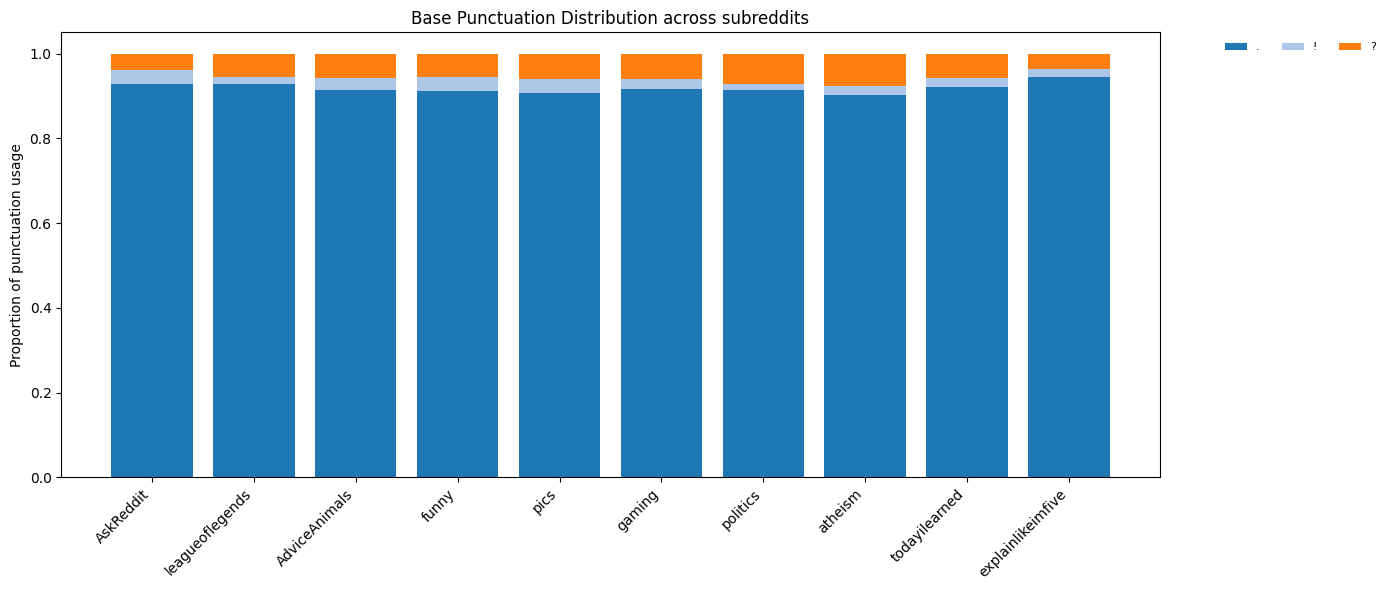

In [14]:
labels = top_10_subs
matrix = []
punct_lookup = {r["subreddit"]: r["punctuation_counts"] for r in results}
for sub in labels:
    counts = punct_lookup[sub]
    matrix.append([counts.get(f, 0) for f in features_base])
matrix = np.array(matrix)
row_sums = matrix.sum(axis=1, keepdims=True)
#converts counts to percentages
norm_matrix = matrix / (row_sums + 1e-9)
#Includes contrasting colours
colors = (
    list(plt.cm.tab20.colors) +
    list(plt.cm.tab20b.colors) +
    list(plt.cm.tab20c.colors)
)
#according to the number of features
colors = colors[:len(features_base)]
plt.figure(figsize=(14,6))
bottom = np.zeros(len(labels))
for i, feat in enumerate(features_base):
    plt.bar(
        labels,
        norm_matrix[:, i],
        bottom=bottom,
        color=colors[i],
        label=feat
    )
    bottom += norm_matrix[:, i]
plt.xticks(rotation=45, ha='right')
plt.ylabel("Proportion of punctuation usage")
plt.title("Base Punctuation Distribution across subreddits")
plt.legend(
    ncol=4,
    fontsize=8,
    bbox_to_anchor=(1.05, 1),
    frameon=False
)
plt.savefig("../figures/EDA_BasePunct_Distribution.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

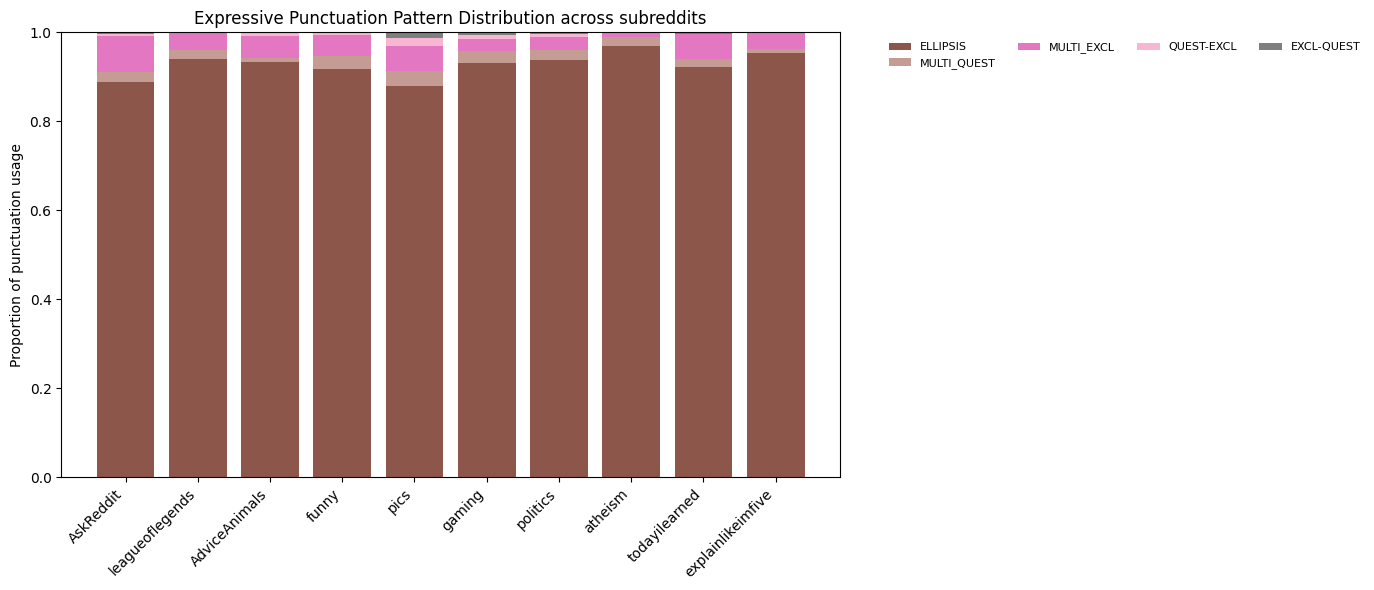

In [15]:
labels = top_10_subs
matrix = []
punct_lookup = {r["subreddit"]: r["punctuation_counts"] for r in results}
for sub in labels:
    counts = punct_lookup[sub]
    matrix.append([counts.get(f, 0) for f in features_exp])
matrix = np.array(matrix)
row_sums = matrix.sum(axis=1, keepdims=True)
#converts counts to percentages
norm_matrix = matrix / (row_sums + 1e-9)
#Includes contrasting colours
colors = (
    list(plt.cm.tab20.colors) +
    list(plt.cm.tab20b.colors) +
    list(plt.cm.tab20c.colors)
)
#different colours than the base punct chart
colors = colors[10:10 + len(features_exp)]
plt.figure(figsize=(14,6))
bottom = np.zeros(len(labels))
for i, feat in enumerate(features_exp):
    plt.bar(
        labels,
        norm_matrix[:, i],
        bottom=bottom,
        color=colors[i],
        label=feat
    )
    bottom += norm_matrix[:, i]
plt.xticks(rotation=45, ha='right')
plt.ylabel("Proportion of punctuation usage")
plt.title("Expressive Punctuation Pattern Distribution across subreddits")
plt.legend(
    ncol=4,
    fontsize=8,
    bbox_to_anchor=(1.05, 1),
    frameon=False
)
plt.savefig("../figures/EDA_ExpressivePatterns_Distribution.png",bbox_inches="tight")
plt.tight_layout()
plt.show()

## Classification - Can Punctuations alone predict each subreddit?
2 classifiers are used to predict the subreddit based on punctuation.

### Frequency per 1000 words
We calculate the punctuation frequency per 1000 words for 1500 posts in groups of 20 for each of the 10 subreddits we chose. Then turn that into a csv file.

In [16]:
GROUP_SIZE = 20

# FEATURE EXTRACTION
def extract_punct_features(text):

    #Tokenization
    tokens = get_tokens(text)

    #Word Counting
    words = [t for t in tokens if t not in string.punctuation]
    n_words = len(words)

    #Handle empty text
    if n_words == 0:
        feats = {p: 0.0 for p in features_base}
        for k in EXPRESSIVE_PATTERNS:
            feats[k] = 0.0
        return feats

    #Punctuation counter
    counts = Counter(t for t in tokens if t in string.punctuation)

    #Normalization of punctuation per word
    feats = {
        p: (counts.get(p, 0) / n_words) * 1000
        for p in features_base
    }

    # expressive punctuation frequencies per 100 words
    for name, pattern in EXPRESSIVE_PATTERNS.items():
        feats[name] = (
            len(re.findall(pattern, text)) / n_words
        ) * 1000

    return feats

# BUILD CSV DATASET
rows = []

for sub in top_10_subs:

    subreddit_posts = get_posts(sub, MAX_POSTS)
    
    # create groups of 20 posts
    for i in range(0, len(subreddit_posts), GROUP_SIZE):

        chunk = subreddit_posts[i:i + GROUP_SIZE]

        if len(chunk) < GROUP_SIZE:
            continue

        combined_text = " ".join(chunk)

        feats = extract_punct_features(combined_text)

        feats["subreddit"] = sub
        feats["group_id"] = i // GROUP_SIZE

        rows.append(feats)

# dataframe
punct_df = pd.DataFrame(rows)

# subreddit first
cols = (
    ["subreddit", "group_id"] +
    [c for c in punct_df.columns
     if c not in ["subreddit", "group_id"]]
)

punct_df = punct_df[cols]

# save
punct_df.to_csv("../data/punctuation_features.csv", index=False)

print("Rows:", len(punct_df))
print("Rows per subreddit:", MAX_POSTS // GROUP_SIZE)
print(punct_df.head())

Rows: 750
Rows per subreddit: 75
   subreddit  group_id          .         !         ?  ELLIPSIS  MULTI_QUEST  \
0  AskReddit         0  47.921360  1.843129  2.457506  1.228753     0.000000   
1  AskReddit         1  59.472318  3.243945  3.027682  2.162630     0.000000   
2  AskReddit         2  53.722903  0.000000  9.425071  2.199183     1.885014   
3  AskReddit         3  58.560000  4.800000  3.840000  1.920000     0.000000   
4  AskReddit         4  52.666519  0.885152  1.991591  1.327727     0.000000   

   MULTI_EXCL  QUEST-EXCL  EXCL-QUEST  
0    0.204792         0.0         0.0  
1    0.216263         0.0         0.0  
2    0.000000         0.0         0.0  
3    0.640000         0.0         0.0  
4    0.000000         0.0         0.0  


### Cosine Similarity of the Subreddits
It finds the cosine similarity based on the punctuations.

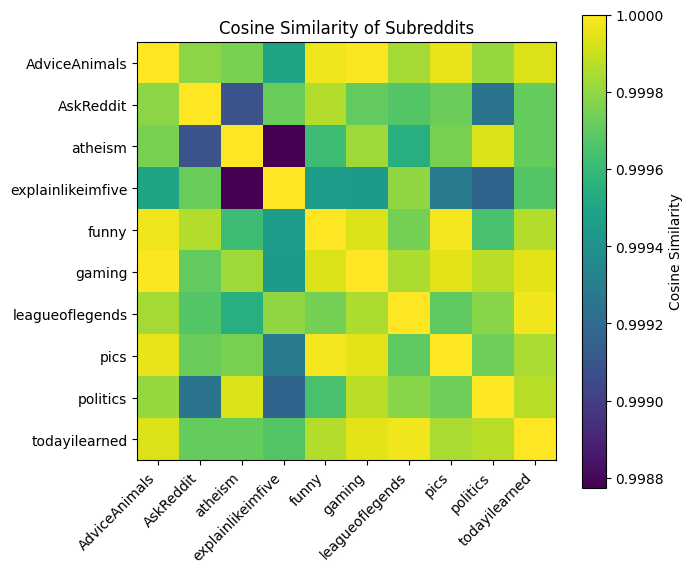

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

# Average punctuation profile for each subreddit
group_means = (
    punct_df
    .drop(columns=["group_id"])
    .groupby("subreddit")
    .mean()
)

# Cosine similarity matrix
cos_sim = cosine_similarity(group_means)

# Plot
plt.figure(figsize=(7, 6))
plt.imshow(cos_sim, cmap="viridis")
plt.colorbar(label="Cosine Similarity")

plt.xticks(range(len(group_means.index)),
           group_means.index,
           rotation=45,
           ha="right")
plt.yticks(range(len(group_means.index)),
           group_means.index)

plt.title("Cosine Similarity of Subreddits")
plt.tight_layout()
plt.savefig("../figures/EDA_CosineSimilarity.png",bbox_inches="tight")
plt.show()

### Classifiers and Scores
We use 2 kinds of classifier to determine if linear separation plays a role.\
Each model studies to find correlation between the punctuation and the subreddit.
1. **Random Forest Classifier**: Here, the guesses of the 200 trees(n_estimator) is then averaged during prediction. Random Forest Classifier learns the rules and takes a majority vote from the different trees.
2. **LinearSVC**: LinearSVC assumes that subreddits can be separated by relatively simple linear relationships between punctuation features.

In [18]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
def evaluate_models(X, y, feature_set_name):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    print(f"\n==================== {feature_set_name} ====================")

    # ---------------- RANDOM FOREST ----------------
    rf = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
    rf.fit(X_train, y_train)

    rf_pred = rf.predict(X_test)

    rf_acc = accuracy_score(y_test, rf_pred)

    print("\n----- Random Forest -----")
    print(f"Accuracy: {rf_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, rf_pred))


    # ---------------- LINEAR SVC ----------------
    svm = LinearSVC(
        random_state=42,
        max_iter=5000
    )
    svm.fit(X_train, y_train)

    svm_pred = svm.predict(X_test)

    svm_acc = accuracy_score(y_test, svm_pred)

    print("\n----- LinearSVC -----")
    print(f"Accuracy: {svm_acc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, svm_pred))


    # return summary (optional for later comparison tables)
    return {
    "Feature Set": feature_set_name,
    "RF Accuracy": rf_acc,
    "LinearSVC Accuracy": svm_acc,
    "rf_model": rf,
    "rf_pred": rf_pred,
    "svm_model": svm,
    "svm_pred": svm_pred,
    "X_test": X_test,
    "y_test": y_test,
}

In [19]:
y = punct_df["subreddit"]

X = punct_df.drop(columns=["subreddit", "group_id"])

cl_res = evaluate_models(X, y, "Expressive Features")


==================== Expressive Features ====================

----- Random Forest -----
Accuracy: 0.1911

Classification Report:
                   precision    recall  f1-score   support

    AdviceAnimals       0.15      0.14      0.14        22
        AskReddit       0.29      0.41      0.34        22
          atheism       0.16      0.13      0.14        23
explainlikeimfive       0.23      0.30      0.26        23
            funny       0.07      0.04      0.05        23
           gaming       0.13      0.18      0.15        22
  leagueoflegends       0.17      0.17      0.17        23
             pics       0.17      0.18      0.17        22
         politics       0.28      0.32      0.30        22
    todayilearned       0.11      0.04      0.06        23

         accuracy                           0.19       225
        macro avg       0.18      0.19      0.18       225
     weighted avg       0.18      0.19      0.18       225


----- LinearSVC -----
Accuracy: 0.2267


### Conclusion:
As LinearSVC has outperformed Random Forest, it means that the punctuations we selected are slightly more linearly seperable. LinearSVC finds a single hyperplane per class, which is more robust when features are weak/noisy

### Visualization
We only consider the results from Random Forest Classification of the all punctuation and expressions set for visualization.
#### 1. Precision-Recall:

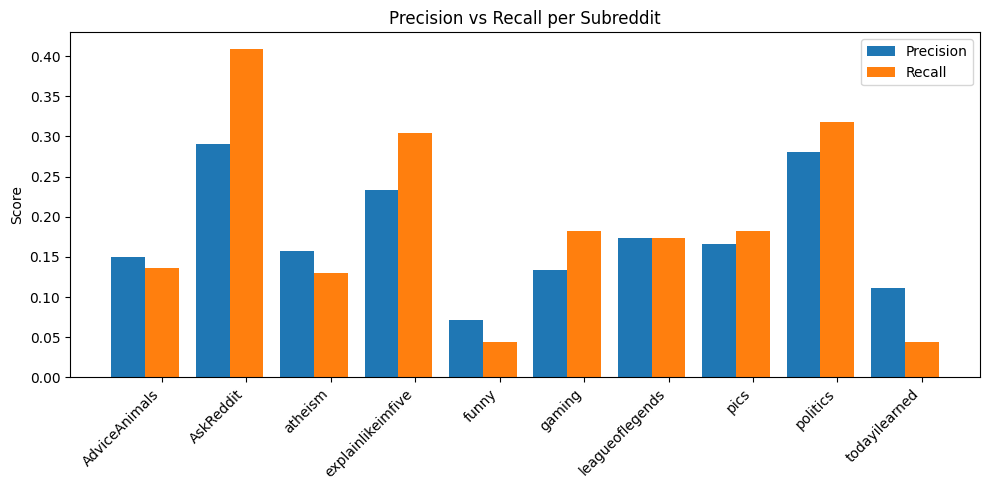

In [20]:
rf = cl_res["rf_model"]
rf_pred = cl_res["rf_pred"]
y_test = cl_res["y_test"]

labels = sorted(set(y))

# REMOVE labels=labels and target_names=labels
report = classification_report(y_test, rf_pred, output_dict=True, zero_division=0)

classes = list(report.keys())[:-3]  # ignore accuracy, macro avg, weighted avg

precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]

x = range(len(classes))

plt.figure(figsize=(10,5))
plt.bar([i-0.2 for i in x], precision, width=0.4, label="Precision")
plt.bar([i+0.2 for i in x], recall, width=0.4, label="Recall")

plt.xticks([i+0.2 for i in x], classes, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Precision vs Recall per Subreddit")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/EDA_Precision_Recall.png", bbox_inches="tight")
plt.show()

High precision and recall (AskReddit, explainlikeimfive, politics) indicate consistent punctuation patterns.
whereas for low precision and recall(funny, todayilearned,) indicate no strong distinguishing feature.

#### 2. Importance Factor of Punctuations

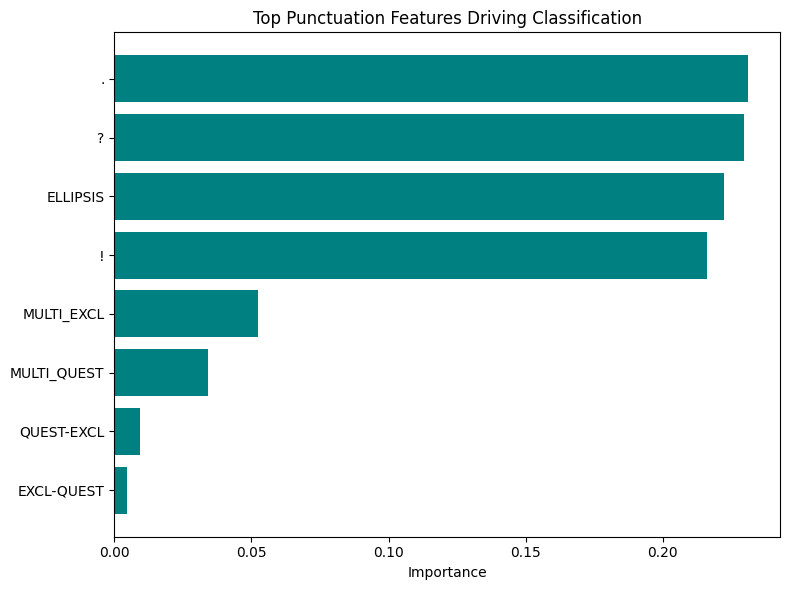

In [21]:
importances = rf.feature_importances_
# remove group_id 
mask = X.columns != "group_id"
features = X.columns[mask]
importances = importances[mask]


idx = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(features[idx], importances[idx], color="teal")

plt.title("Top Punctuation Features Driving Classification")
plt.xlabel("Importance")

plt.tight_layout()
plt.savefig("../figures/EDA_Top_Puncts_Rfc.png", bbox_inches="tight")
plt.show()

## Sentiment Analysis
For Sentiment Analysis VADER from nltk model is used. It was trained on social media text and uses punctuation to signal increased sentiment intensity.

### Model Seutup and Data Acquisition
We determine 3 labels: positive, negative, neutral. A Dataframe is created where each subreddit has 300 posts For each post, the frequencies of the chosen punctuations are saved as well as the sentiment predictions(with and w/o punctuations) and a 'Flipped' value.
Flipped returns true if punctuation changes a sentiment and False otherwise.

In [22]:
try:
    nltk.data.find("sentiment/vader_lexicon.zip/vader_lexicon/vader_lexicon.txt")
except LookupError:
    nltk.download("vader_lexicon")

In [23]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

def strip_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))
    
analyzer = SentimentIntensityAnalyzer()

def vader_label(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:   return "positive"
    elif score <= -0.05: return "negative"
    else:                return "neutral"

MAX_POSTS_PER_SUB = 300

rows = []
for sub in top_10_subs:
    posts = get_posts(sub, MAX_POSTS_PER_SUB)
    for text in posts:
        rows.append({
            "subreddit": sub,
            "label_with_punct": vader_label(text),
            "label_without_punct": vader_label(strip_punctuation(text)),
            **extract_punct_features(text)
        })

topic_df = pd.DataFrame(rows)
topic_df["flipped"] = topic_df["label_with_punct"] != topic_df["label_without_punct"]

In [24]:
topic_df.to_csv("../data/post_sentiment.csv", index=False)

### Examples of falsely identified Sentiments

In [25]:
total_flipped = topic_df["flipped"].sum()
print(f"Total flipped: {total_flipped} out of {len(topic_df)} posts ({total_flipped/len(topic_df):.1%})")
print()

# build text series in same order as topic_df
all_texts = [text for sub in top_10_subs for text in get_posts(sub, MAX_POSTS_PER_SUB)]
topic_df["text"] = all_texts

flipped = topic_df[topic_df["flipped"]].head(5)
for _, row in flipped.iterrows():
    print(f"r/{row['subreddit']}")
    print(f"POST: {row['text'][:300]}")
    print(f"with punct:    {row['label_with_punct']}")
    print(f"without punct: {row['label_without_punct']}")
    print("-" * 60)

Total flipped: 95 out of 3000 posts (3.2%)

r/AskReddit
POST: You would be pretty if you didn't have all that acne." Although I realized when I was older that it likely was intentional. She was constantly criticizing me, likely to feel better about herself. She did while acting as though she was my 'friend.' that was the most hurtful thing she said though. I c
with punct:    negative
without punct: positive
------------------------------------------------------------
r/AskReddit
POST: With use of intellect, lies and confidence there isn't much you couldn't do. 
 First you need to avoid getting to well known at first, you might get killed.
Gather a small base of followers and lead them to victory time and time again and gather a much larger group. 
 Gain some power in a country an
with punct:    neutral
without punct: negative
------------------------------------------------------------
r/AskReddit
POST: Summer of 2011. Last day of high school senior. Left school early to go on the lake

### Accuracy Detection
Again Random Forest Classifier is used to detect the accuracies with and without punctuations.

In [26]:
X = topic_df[EXPRESSIVE_FEATURES]
X_train, X_test, yw_train, yw_test, ywo_train, ywo_test = train_test_split(
    X, topic_df["label_with_punct"], topic_df["label_without_punct"],
    test_size=0.3, random_state=42, stratify=topic_df["label_with_punct"]
)

clf_with = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, yw_train)
clf_without = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, ywo_train)

acc_with = accuracy_score(yw_test, clf_with.predict(X_test))
acc_without = accuracy_score(ywo_test, clf_without.predict(X_test))

print(f"Accuracy WITH punctuation sentiment:    {acc_with:.3f}")
print(f"Accuracy WITHOUT punctuation sentiment: {acc_without:.3f}")

Accuracy WITH punctuation sentiment:    0.497
Accuracy WITHOUT punctuation sentiment: 0.481


#### Overall Accuracy

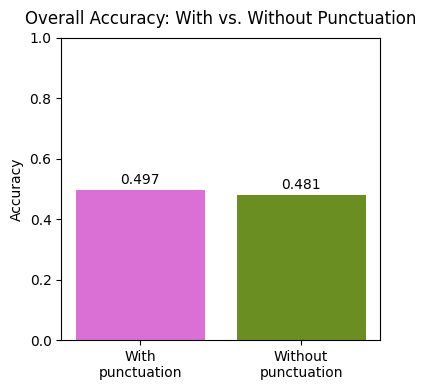

In [27]:
plt.figure(figsize=(4, 4))
bars = plt.bar(
    ["With\npunctuation", "Without\npunctuation"],
    [acc_with, acc_without],
    color=["orchid", "olivedrab"]
)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Overall Accuracy: With vs. Without Punctuation", pad=10)
for bar, v in zip(bars, [acc_with, acc_without]):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout()
plt.savefig("../figures/EDA_Overall_Accuracy_Comparison.png", bbox_inches="tight")
plt.show()

#### Per Subreddit Accuracy

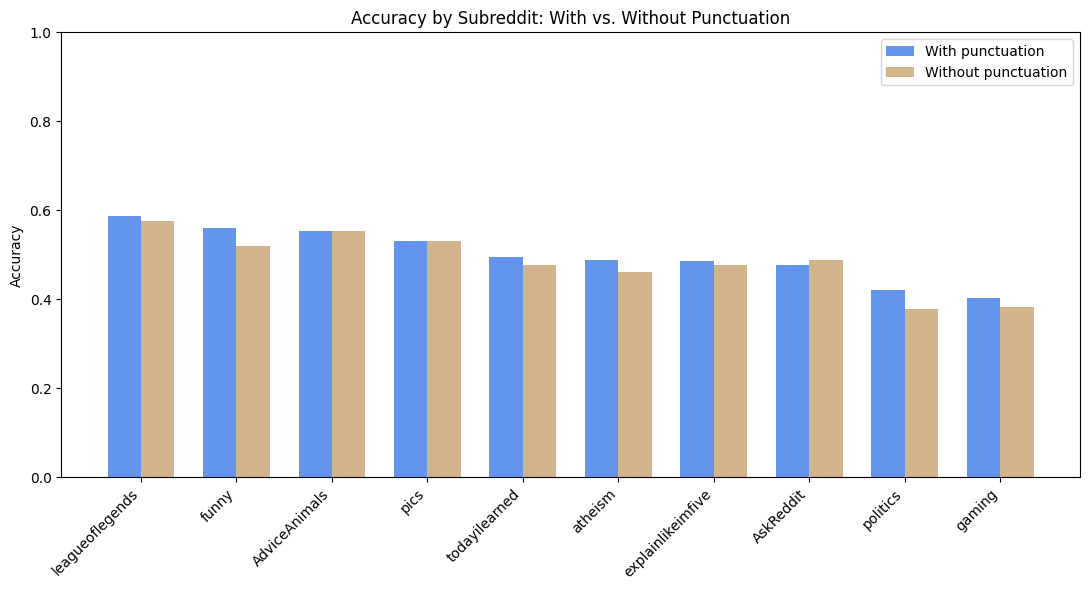

In [28]:
# recover which subreddit each test row belongs to, plus predictions
test_info = X_test.copy()
test_info["subreddit"] = topic_df.loc[X_test.index, "subreddit"]
test_info["true_with"] = yw_test.values
test_info["true_without"] = ywo_test.values
test_info["pred_with"] = clf_with.predict(X_test)
test_info["pred_without"] = clf_without.predict(X_test)

per_sub_rows = []
for sub in top_10_subs:
    rows_sub = test_info[test_info["subreddit"] == sub]
    if len(rows_sub) == 0:
        continue
    per_sub_rows.append({
        "subreddit": sub,
        "acc_with": accuracy_score(rows_sub["true_with"], rows_sub["pred_with"]),
        "acc_without": accuracy_score(rows_sub["true_without"], rows_sub["pred_without"]),
    })

per_sub_df = pd.DataFrame(per_sub_rows).sort_values("acc_with", ascending=False)

x = np.arange(len(per_sub_df))
width = 0.35

plt.figure(figsize=(11, 6))
plt.bar(x - width / 2, per_sub_df["acc_with"], width, label="With punctuation", color="cornflowerblue")
plt.bar(x + width / 2, per_sub_df["acc_without"], width, label="Without punctuation", color="tan")
plt.xticks(x, per_sub_df["subreddit"], rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Accuracy by Subreddit: With vs. Without Punctuation")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/EDA_Accuracy_per_Subreddit.png", bbox_inches="tight")
plt.show()

#### Clustering Subreddits by Sentiment Labels
K-Means is used to clusters subreddits with similar sentiments.

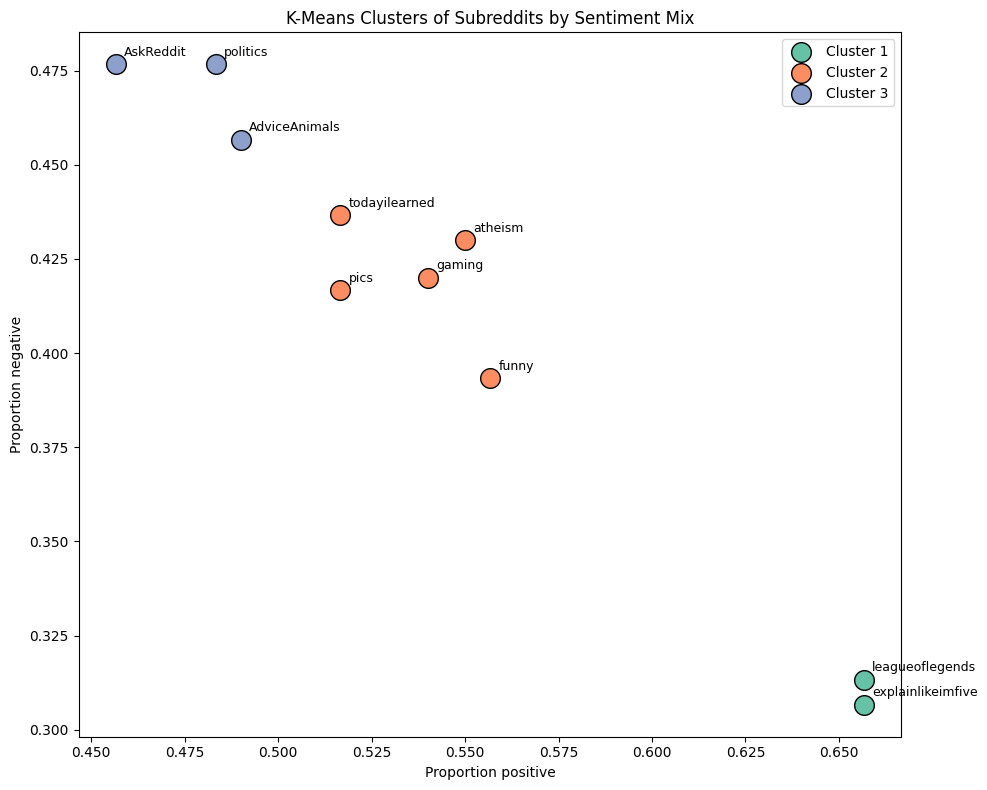

label_with_punct,positive,neutral,negative,cluster
subreddit,,,,
explainlikeimfive,0.656667,0.036667,0.306667,1
leagueoflegends,0.656667,0.030000,0.313333,1
atheism,0.550000,0.020000,0.430000,2
funny,0.556667,0.050000,0.393333,2
gaming,0.540000,0.040000,0.420000,2
pics,0.516667,0.066667,0.416667,2
todayilearned,0.516667,0.046667,0.436667,2
AdviceAnimals,0.490000,0.053333,0.456667,3
AskReddit,0.456667,0.066667,0.476667,3


In [29]:
from sklearn.cluster import KMeans

# build positive/neutral/negative proportions per subreddit
sent_counts = topic_df.groupby("subreddit")["label_with_punct"].value_counts(normalize=True).unstack(fill_value=0)#as decimal values
for lbl in ["positive", "neutral", "negative"]:
    if lbl not in sent_counts.columns: #ensures all 3 sentiments exist
        sent_counts[lbl] = 0.0
sent_counts = sent_counts[["positive", "neutral", "negative"]]

# cluster subreddits based on their sentiment proportions
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
sent_counts["cluster"] = kmeans.fit_predict(sent_counts[["positive", "neutral", "negative"]]) + 1  # start at 1

plt.figure(figsize=(10, 8))
cluster_colors = plt.cm.Set2.colors
for cl in sorted(sent_counts["cluster"].unique()):
    rows = sent_counts[sent_counts["cluster"] == cl]
    plt.scatter(rows["positive"], rows["negative"], s=200, color=cluster_colors[cl - 1],
                label=f"Cluster {cl}", edgecolors="black")
    for sub in rows.index:
        plt.annotate(sub, (rows.loc[sub, "positive"], rows.loc[sub, "negative"]),
                      textcoords="offset points", xytext=(6, 6), fontsize=9)
plt.xlabel("Proportion positive")
plt.ylabel("Proportion negative")
plt.title("K-Means Clusters of Subreddits by Sentiment Mix")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/EDA_Sentiment_Clusters_by_Subreddit.png", bbox_inches="tight")
plt.show()

# show the full sent_counts table, sorted by cluster
sent_counts.sort_values("cluster")

#### Dominant Sentiments of the Punctuations

In [30]:
# average punctuation usage per sentiment label
pattern_by_sentiment = topic_df.groupby("label_with_punct")[EXPRESSIVE_FEATURES].mean()

# L1 Normalization
pattern_by_sentiment_norm = pattern_by_sentiment.div(pattern_by_sentiment.sum(axis=0), axis=1)

# selects the dominant sentiment
dominant_sentiment = pattern_by_sentiment_norm.idxmax(axis=0)

punct_sentiment_table = pd.DataFrame({
    "punctuation": EXPRESSIVE_FEATURES,
    "dominant_sentiment": [dominant_sentiment[p] for p in EXPRESSIVE_FEATURES]
}).sort_values("dominant_sentiment")
punct_sentiment_table

,punctuation,dominant_sentiment
1,MULTI_QUEST,negative
2,MULTI_EXCL,negative
6,!,negative
0,ELLIPSIS,neutral
5,.,neutral
7,?,neutral
3,QUEST-EXCL,positive
4,EXCL-QUEST,positive


In [31]:
punct_sentiment_table.to_csv("../data/punct_dominant_sentiment.csv", index=False)